In [1]:
import os
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import torch
import argparse
from nnfabrik.builder import get_data, get_trainer

from modified_neuralpredictors.create_model import stacked_core_full_gauss_readout
from modified_neuralpredictors.wandb_trainer import standard_trainer

random_seed = 42
torch.manual_seed(random_seed)
np.random.seed(random_seed)

device = 'cuda:0'
torch.cuda.set_device(device)

basepath = "/srv/user/polina/sensorium/sensorium/notebooks/data/"

# as filenames, we'll select all 7 datasets
filenames = [
    os.path.join(basepath, file) for file in os.listdir(basepath) if ".zip" in file
]

dataset_fn = "sensorium.datasets.static_loaders"
dataset_config = {
    "paths": filenames,
    "normalize": True,
    "include_behavior": True,
    "include_eye_position": True,
    "batch_size": 128,
    "scale": 0.25,
}

dataloaders = get_data(dataset_fn, dataset_config)
data_keys = list(dataloaders['train'].keys())

model_config = {
    'hidden_channels': 64, # original sensorium was 64ch
    'depth_separable': False,
    'use_avg_reg': False,
    'laplace_padding': None,
    'momentum': 0.75,
    'final_nonlinearity': True,
    'nonlinearity_type': 'AdaptiveELU',
    'pad_input': False,
    'stack': -1,
    'layers': 4,
    'input_kern': 11, #  original sensorium was 'input_kern': 9,
    'gamma_input': 6.3831, # this should not influence the performance based on previous experience
    
    'feature_reg_weight': 3, # this is the one I actually would like to tune!
    
    'hidden_kern': 7,
    'grid_mean_predictor': {
        'type': 'cortex',
        'input_dimensions': 2,
        'hidden_layers': 1,
        'hidden_features': 30,
        'final_tanh': True
    },
    
    'init_sigma': 0.1,
    'init_mu_range': 0.3,
    'gauss_type': 'full',
    'shifter': True,
    'batch_norm_scale': [True, True, True, False],
    'core_bias': [True, True, True, False],
    'regularizer_type': "adaptive_log_norm",
    'gamma_sigma' : 0.25,
}

model = stacked_core_full_gauss_readout(dataloaders, random_seed, **model_config)
model.to(device);
model.train()

Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
/srv/user/nathanpaul.soeding/neuralpredictors/neuralpredictors/layers/readouts/base.py:95: UserWarning: Readout is NOT initialized with mean activity but with 0!
  warnings.warn("Readout is NOT initialized with mean activity but with 0!")


FiringRateEncoder(
  (core): Stacked2dCore(
    (_input_weights_regularizer): LaplaceL2norm(
      (laplace): Laplace()
    )
    (features): Sequential(
      (layer0): Sequential(
        (conv): Conv2d(4, 64, kernel_size=(11, 11), stride=(1, 1), bias=False)
        (norm): BatchNorm2d(64, eps=1e-05, momentum=0.75, affine=True, track_running_stats=True)
        (nonlin): AdaptiveELU()
      )
      (layer1): Sequential(
        (conv): Conv2d(64, 64, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3))
        (norm): BatchNorm2d(64, eps=1e-05, momentum=0.75, affine=True, track_running_stats=True)
        (nonlin): AdaptiveELU()
      )
      (layer2): Sequential(
        (conv): Conv2d(64, 64, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3))
        (norm): BatchNorm2d(64, eps=1e-05, momentum=0.75, affine=True, track_running_stats=True)
        (nonlin): AdaptiveELU()
      )
      (layer3): Sequential(
        (conv): Conv2d(64, 64, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3)

In [190]:
model.core.features

Sequential(
  (layer0): Sequential(
    (conv): Conv2d(4, 64, kernel_size=(11, 11), stride=(1, 1), bias=False)
    (norm): BatchNorm2d(64, eps=1e-05, momentum=0.75, affine=True, track_running_stats=True)
    (nonlin): AdaptiveELU()
  )
  (layer1): Sequential(
    (conv): Conv2d(64, 64, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3))
    (norm): BatchNorm2d(64, eps=1e-05, momentum=0.75, affine=True, track_running_stats=True)
    (nonlin): AdaptiveELU()
  )
  (layer2): Sequential(
    (conv): Conv2d(64, 64, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3))
    (norm): BatchNorm2d(64, eps=1e-05, momentum=0.75, affine=True, track_running_stats=True)
    (nonlin): AdaptiveELU()
  )
  (layer3): Sequential(
    (conv): Conv2d(64, 64, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3))
    (norm): BatchNorm2d(64, eps=1e-05, momentum=0.75, affine=False, track_running_stats=True)
    (nonlin): AdaptiveELU()
  )
)

In [2]:
paths = [
    'runs/newbase/dim64_seed0/model_weights.pth',
    'runs/newbase/dim64_seed42/model_weights.pth',
    'runs/newbase/dim64_seed123/model_weights.pth',
]

In [3]:
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score

def knn_consistency(knn1, knn2, ks):
    N, k_max = knn1.shape
    #idcs = torch.randperm(N)
    #knn2 = knn2[idcs]
    
    assert ks[-1] <= k_max 
    ranking = np.full((N, N), N, dtype=np.int32)  # Shape (N, N)
    ranking[np.arange(N)[:, None], knn1] = np.arange(k_max)[None]
    overlaps = []

    for k in ks:
        neighbours = knn2[:, :k]  # Shape (N, k)
        shared = ranking[np.arange(N)[:, None], neighbours] < k  # Shape (N, k)
        num_shared = shared.sum() / N
        
        overlap = num_shared / k
        overlaps.append(overlap)

    return np.array(overlaps)

def get_curve(k_range, all_features):
    knns = []
    for features in all_features:
        nn = NearestNeighbors(n_neighbors=k_range[-1]).fit(features)
        knn = nn.kneighbors(return_distance=False)
        knns.append(knn)

    #for leniency in leniency_range:
    x_idcs, y_idcs = np.tril_indices(len(all_features), k=-1)
    constistencies = []
    for x, y in zip(x_idcs, y_idcs):
        constistencies.append(knn_consistency(knns[x], knns[y], ks=k_range))
    constistencies = np.column_stack(constistencies)

    mean_curve = constistencies.mean(axis=1)
    std_curve = constistencies.std(axis=1, ddof=1)

    return mean_curve, std_curve

def get_ari_curve(n_clusters_range, all_features):
    def cluster(points, n_clusters):
        kmeans = KMeans(n_clusters=n_clusters, random_state=42)
        labels = kmeans.fit_predict(points)
        return labels
    
    mean_curve = []
    std_curve = []
    for n in n_clusters_range:
        labels = [cluster(features, n) for features in all_features]

        x_idcs, y_idcs = np.tril_indices(len(all_features), k=-1)
        aris = np.array([
            adjusted_rand_score(labels[x], labels[y]) for x, y in zip(x_idcs, y_idcs)
        ])

        ari_mean = aris.mean()
        ari_std = aris.std(ddof=1)
        mean_curve.append(ari_mean)
        std_curve.append(ari_std)
    
    return mean_curve, std_curve

In [4]:
num_batches = 1

knns = []
embeds = []
for path in paths:
    model = stacked_core_full_gauss_readout(dataloaders, random_seed, **model_config)
    model.load_state_dict(torch.load(path, map_location=device))
    model.to(device);
    model.train();
    
    preds = []
    for loader_key in data_keys:
        batch_num = 0
        for batch in dataloaders['validation'][loader_key]:
            batch_num += 1

            img, _, _, pupil = batch
            
            all_mice_preds = []
            for key in data_keys:
                pred, vec = model(img, data_key=key, pupil_center=pupil)
                all_mice_preds.append(pred.detach().cpu())
                
            all_mice_preds = torch.cat(all_mice_preds, dim=1)
            preds.append(all_mice_preds)

            if batch_num == num_batches:
                break
            
    preds = torch.cat(preds).T  # (neurons, images)
    pred_corr = torch.corrcoef(preds)  # (neurons, neurons)
    knn = pred_corr.argsort(dim=1).flip(1)[:, 1:]
    knns.append(knn)
    embeddings = torch.cat([model.readout[key].features.data.squeeze().cpu().T for key in data_keys])
    embeds.append(embeddings)

Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.


In [5]:
def get_corr_curve(k_range, knns):
    x_idcs, y_idcs = np.tril_indices(len(knns), k=-1)
    constistencies = []
    for x, y in zip(x_idcs, y_idcs):
        constistencies.append(knn_consistency(knns[x], knns[y], ks=k_range))
    constistencies = np.column_stack(constistencies)

    mean_curve = constistencies.mean(axis=1)
    std_curve = constistencies.std(axis=1, ddof=1)

    return mean_curve, std_curve

k_range = np.unique(np.geomspace(1, 100, num=10, dtype=int))
corr_curve = get_corr_curve(k_range, knns)

In [16]:
emb_curve = get_curve(k_range, embeds)

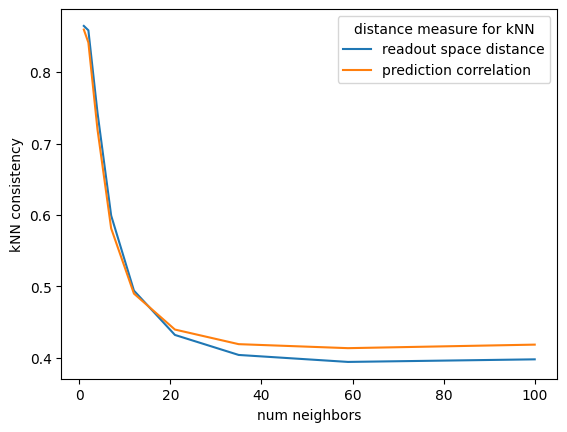

In [18]:
plt.plot(k_range, emb_curve[0], label='readout space distance')
plt.plot(k_range, corr_curve[0], label='prediction correlation')
plt.xlabel('num neighbors')
plt.ylabel('kNN consistency')
plt.legend(title='distance measure for kNN')
plt.show()

In [177]:
model = stacked_core_full_gauss_readout(dataloaders, random_seed, **model_config)
model.load_state_dict(torch.load(paths[0], map_location=device))
model.to(device);
model.train();

num_batches = 5

grids = []
shifts = []

for key in data_keys:
    grid = model.readout[key].sample_grid(1, sample=False).detach().cpu()
    grid_mean = grid.squeeze().mean(0, keepdim=True)
    grid_centered = grid - grid_mean
    
    batch_num = 0

    shifts_batches = []
    for batch in dataloaders['train'][key]:
        batch_num += 1
        img, _, _, pupil = batch
        shift = model.shifter[key](pupil, None).detach().cpu()
        shift = shift + grid_mean
        shifts_batches.append(shift)

        if batch_num == num_batches:
            break
        

    grids.append(grid_centered)
    shifts.append(torch.cat(shifts_batches))

Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
/srv/user/nathanpaul.soeding/neuralpredictors/neuralpredictors/layers/readouts/base.py:95: UserWarning: Readout is NOT initialized with mean activity but with 0!
  warnings.warn("Readout is NOT initialized with mean activity but with 0!")


In [178]:
model.readout[data_keys[4]].mu

tensor([[[[-0.1420, -0.7215]],

         [[-0.1418, -0.7263]],

         [[-0.1367, -0.7097]],

         ...,

         [[-0.1372, -0.7259]],

         [[-0.2554, -0.6299]],

         [[-0.3163, -0.4342]]]], device='cuda:0', grad_fn=<ViewBackward0>)

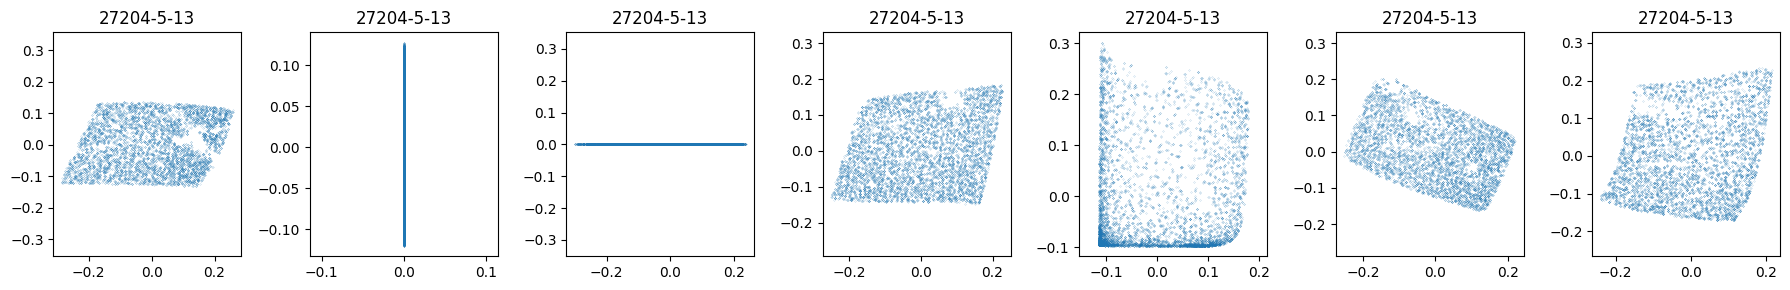

In [91]:
fig, axs = plt.subplots(1, 7, figsize=(18, 3))

for ax, grid in zip(axs, grids):
    ax.scatter(grid.squeeze()[:, 0], grid.squeeze()[:, 1], s=0.01, label=key)
    ax.axis('equal')
    ax.set_title(key)
    # ax.set_xticks([])
    # ax.set_yticks([])
    # ax.spines.clear()

plt.tight_layout()
plt.show()

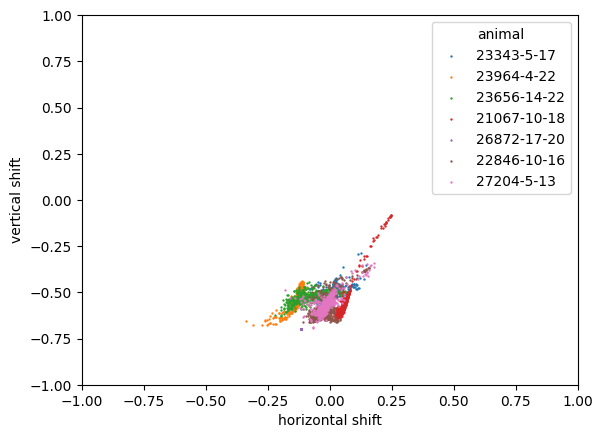

In [92]:
for shift, key in zip(shifts, data_keys):
    plt.scatter(shift[:, 0], shift[:, 1], s=.5, label=key)

plt.xlim(-1, 1)
plt.ylim(-1, 1)
plt.xlabel('horizontal shift')
plt.ylabel('vertical shift')
plt.legend(title='animal')
plt.show()

In [179]:
readouts = torch.cat([model.readout[key].features.detach().cpu().squeeze().T for key in data_keys])

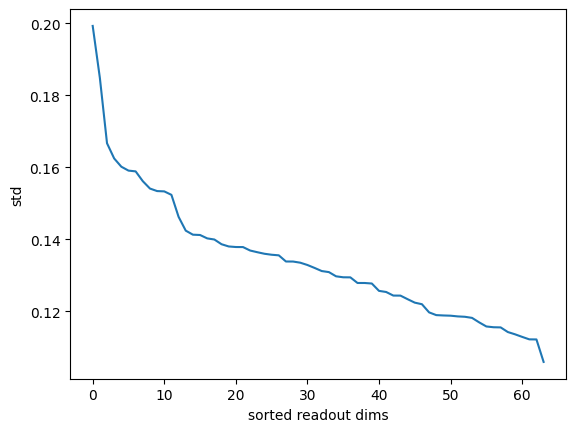

In [180]:
# means = readouts.mean(0).sort().values.flip(0)
stds = readouts.std(0).sort().values.flip(0)

# plt.plot(range(64), means)
plt.plot(range(64), stds)
plt.xlabel('sorted readout dims')
plt.ylabel('std')
#plt.ylim(0)
plt.show()

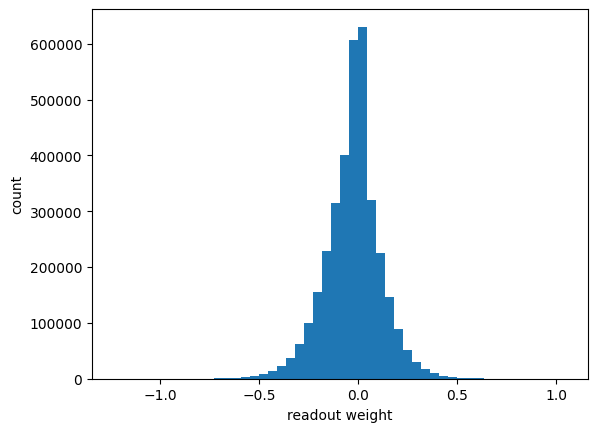

In [184]:
plt.hist(readouts.flatten(), bins=50)
plt.xlabel('readout weight')
plt.ylabel('count')
plt.show()